In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# !pip install -q torch_geometric
# !pip install -q class_resolver
# !pip3 install pymatting

In [127]:
import numpy as np
import torch
import random
import copy
import scipy.sparse as sp

from torch.utils.data import TensorDataset, DataLoader, Subset
from torchvision import models
import torch.nn as nn
import torch.nn.functional as nnFn

# torch-geometric imports
from torch_geometric.nn import ARMAConv
from torch_geometric.data import Data
from sklearn.metrics import roc_auc_score, roc_curve, normalized_mutual_info_score


In [128]:
import torch
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU Name: NVIDIA RTX A4000


In [ ]:
# import torch
# import torch.nn as nn
# import torchvision.models as models
# import numpy as np
# import random
# from torch.utils.data import TensorDataset, DataLoader, Subset

# device = "cuda" if torch.cuda.is_available() else "cpu"

# # ===============================
# # LOAD DATA (same as yours)
# # ===============================
# data = np.load('/home/snu/Downloads/breastmnist_224.npz', allow_pickle=True)

# all_images = np.concatenate([
#     data['train_images'],
#     data['val_images'],
#     data['test_images']
# ], axis=0)

# all_labels = np.concatenate([
#     data['train_labels'],
#     data['val_labels'],
#     data['test_labels']
# ], axis=0).squeeze()

# images = all_images.astype(np.float32) / 255.0
# images = np.repeat(images[:, None, :, :], 3, axis=1)

# X = torch.tensor(images)
# y = torch.tensor(all_labels).long()

# print("Images, labels shapes:", X.shape, y.shape)

# dataset = TensorDataset(X, y)

# # balance dataset
# class0_indices = [i for i in range(len(y)) if y[i] == 0]
# class1_indices = [i for i in range(len(y)) if y[i] == 1]

# random.seed(42)
# sampled_class0 = random.sample(class0_indices, min(1000, len(class0_indices)))
# sampled_class1 = random.sample(class1_indices, min(1000, len(class1_indices)))

# combined_indices = sampled_class0 + sampled_class1
# random.shuffle(combined_indices)

# final_dataset = Subset(dataset, combined_indices)
# final_loader = DataLoader(final_dataset, batch_size=64, shuffle=False)

# # ===============================
# # LOAD RADIMAGENET RESNET50
# # ===============================
# model = models.resnet50(pretrained=False)

# # load RadImageNet weights
# state_dict = torch.load('/home/snu/Downloads/ResNet50.pt', map_location='cpu')

# # clean keys (avoid mismatch issues)
# model_dict = model.state_dict()
# filtered_dict = {k: v for k, v in state_dict.items() if k in model_dict and v.size() == model_dict[k].size()}

# model_dict.update(filtered_dict)
# model.load_state_dict(model_dict)

# # remove classifier → feature extractor
# model = nn.Sequential(*list(model.children())[:-1])

# model = model.to(device)
# model.eval()

# print("✓ RadImageNet model loaded")

# # ===============================
# # FEATURE EXTRACTION
# # ===============================
# features_list = []
# y_list = []

# # ImageNet normalization (important)
# mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
# std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

# with torch.no_grad():
#     for imgs, lbls in final_loader:
#         imgs = imgs.to(device)

#         # normalize
#         imgs = (imgs - mean) / std

#         feats = model(imgs)              # (B, 2048, 1, 1)
#         feats = feats.view(feats.size(0), -1)  # (B, 2048)

#         features_list.append(feats.cpu())
#         y_list.extend(lbls.cpu().tolist())

# # ===============================
# # FINAL FEATURES
# # ===============================
# features = torch.cat(features_list, dim=0).numpy().astype(np.float32)
# y_labels = np.array(y_list).astype(np.int64)

# print("Feature shape:", features.shape)   # (N, 2048)
# print("Label shape:", y_labels.shape)

# # ===============================
# # OPTIONAL: BETTER PREPROCESSING
# # ===============================
# from sklearn.preprocessing import normalize
# from sklearn.decomposition import PCA

# # normalize
# features = normalize(features)

# # PCA + whitening
# features = PCA(n_components=256, whiten=True).fit_transform(features)

# # normalize again
# features = normalize(features)

# print("Processed feature shape:", features.shape)

Images, labels shapes: torch.Size([780, 3, 224, 224]) torch.Size([780])
✓ RadImageNet model loaded
Feature shape: (780, 2048)
Label shape: (780,)
Processed feature shape: (780, 256)


In [129]:
data = np.load('/home/snu/Downloads/breastmnist_224.npz', allow_pickle=True)

In [130]:
all_images = np.concatenate([data['train_images'], data['val_images'], data['test_images']], axis=0)
all_labels = np.concatenate([data['train_labels'], data['val_labels'], data['test_labels']], axis=0).squeeze()

images = all_images.astype(np.float32) / 255.0
images = np.repeat(images[:, None, :, :], 3, axis=1)  # (N,3,224,224)

X = torch.tensor(images)
y = torch.tensor(all_labels).long()
print("Images, labels shapes:", X.shape, y.shape)

dataset = TensorDataset(X, y)
class0_indices = [i for i in range(len(y)) if y[i] == 0]
class1_indices = [i for i in range(len(y)) if y[i] == 1]

random.seed(42)
sampled_class0 = random.sample(class0_indices, min(1000, len(class0_indices)))
sampled_class1 = random.sample(class1_indices, min(1000, len(class1_indices)))

combined_indices = sampled_class0 + sampled_class1
random.shuffle(combined_indices)

final_dataset = Subset(dataset, combined_indices)
final_loader = DataLoader(final_dataset, batch_size=64, shuffle=False)

Images, labels shapes: torch.Size([780, 3, 224, 224]) torch.Size([780])


In [131]:
import torch
import timm
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

vit = torch.hub.load('facebookresearch/dino:main', 'dino_vitb16')
vit.eval().to(device)

vit_feats = []
y_list = []

with torch.no_grad():
    for imgs, lbls in final_loader:
        imgs = imgs.to(device)
        feats = vit(imgs)
        vit_feats.append(feats.cpu())
        y_list.extend(lbls.cpu().tolist())

F = torch.cat(vit_feats, dim=0).numpy().astype(np.float32)
y_labels = np.array(y_list).astype(np.int64)

print("Feature shape:", F.shape)
print("Label shape:", y_labels.shape)
features = F

Using cache found in /home/snu/.cache/torch/hub/facebookresearch_dino_main


Feature shape: (780, 768)
Label shape: (780,)


In [ ]:
# import torch
# import numpy as np
# import random
# import cv2
# from torch.utils.data import TensorDataset, DataLoader, Subset

# device = "cuda" if torch.cuda.is_available() else "cpu"

# # ===============================
# # LOAD DATA
# # ===============================
# data = np.load('/home/snu/Downloads/breastmnist_224.npz', allow_pickle=True)

# all_images = np.concatenate([
#     data['train_images'],
#     data['val_images'],
#     data['test_images']
# ], axis=0)

# all_labels = np.concatenate([
#     data['train_labels'],
#     data['val_labels'],
#     data['test_labels']
# ], axis=0).squeeze()

# # ===============================
# # ULTRASOUND PREPROCESSING
# # ===============================
# def preprocess_ultrasound_batch(images):
#     processed = []

#     for img in images:
#         # img shape: (224,224)
#         img = (img * 255).astype(np.uint8)

#         # CLAHE (contrast enhancement)
#         clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#         img = clahe.apply(img)

#         # Gaussian blur (reduce speckle noise)
#         img = cv2.GaussianBlur(img, (3,3), 0)

#         img = img.astype(np.float32) / 255.0
#         processed.append(img)

#     return np.stack(processed)


# images = preprocess_ultrasound_batch(all_images)

# # Convert to 3-channel for ViT
# images = np.repeat(images[:, None, :, :], 3, axis=1)

# X = torch.tensor(images)
# y = torch.tensor(all_labels).long()

# print("Images, labels shapes:", X.shape, y.shape)

# # ===============================
# # BALANCE DATASET
# # ===============================
# dataset = TensorDataset(X, y)

# class0 = [i for i in range(len(y)) if y[i] == 0]
# class1 = [i for i in range(len(y)) if y[i] == 1]

# random.seed(42)
# class0 = random.sample(class0, min(1000, len(class0)))
# class1 = random.sample(class1, min(1000, len(class1)))

# indices = class0 + class1
# random.shuffle(indices)

# final_dataset = Subset(dataset, indices)
# loader = DataLoader(final_dataset, batch_size=64, shuffle=False)

# # ===============================
# # LOAD DINOv2 (STRONG ViT)
# # ===============================
# vit = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
# vit.eval().to(device)

# # ===============================
# # FEATURE EXTRACTION
# # ===============================
# features_list = []
# labels_list = []

# # ImageNet normalization (VERY IMPORTANT)
# mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
# std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

# with torch.no_grad():
#     for imgs, lbls in loader:
#         imgs = imgs.to(device)

#         # normalize
#         imgs = (imgs - mean) / std

#         feats = vit(imgs)  # (B, 768)

#         features_list.append(feats.cpu())
#         labels_list.extend(lbls.tolist())

# features = torch.cat(features_list).numpy().astype(np.float32)
# y_labels = np.array(labels_list)

# print("Feature shape:", features.shape)
# print("Label shape:", y_labels.shape)

# # ===============================
# # FEATURE DENOISING (IMPORTANT)
# # ===============================
# from sklearn.preprocessing import normalize
# from sklearn.decomposition import PCA

# # normalize
# features = normalize(features)

# # PCA + whitening
# features = PCA(n_components=256, whiten=True).fit_transform(features)

# # normalize again
# features = normalize(features)

# print("Processed feature shape:", features.shape)

# # ===============================
# # QUALITY CHECK
# # ===============================
# from sklearn.metrics.pairwise import cosine_similarity

# S = cosine_similarity(features)
# np.fill_diagonal(S, 0)

# label_mat = (y_labels[:,None] == y_labels[None,:])
# np.fill_diagonal(label_mat, False)

# gap = S[label_mat].mean() - S[~label_mat].mean()

# print(f"Separation gap: {gap:.4f}",
#       "✓ GOOD" if gap > 0.05 else "⚠ FAIR" if gap > 0.02 else "✗ NOISY")

Images, labels shapes: torch.Size([780, 3, 224, 224]) torch.Size([780])


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /home/snu/.cache/torch/hub/main.zip
/home/snu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/snu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/snu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /home/snu/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth
100%|████████████████████████████████████████| 330M/330M [00:03<00:00, 93.2MB/s]


Feature shape: (780, 768)
Label shape: (780,)
Processed feature shape: (780, 256)
Separation gap: 0.0026 ✗ NOISY


In [132]:
def sim(h1, h2, tau=0.2):
    z1 = nnFn.normalize(h1, dim=-1, p=2)
    z2 = nnFn.normalize(h2, dim=-1, p=2)
    return torch.mm(z1, z2.t()) / tau

def contrastive_loss_wo_cross_network(h1, h2, z):
    f = lambda x: torch.exp(x)
    intra_sim = f(sim(h1, h1))
    inter_sim = f(sim(h1, h2))
    return -torch.log(inter_sim.diag() /
                     (intra_sim.sum(dim=-1) + inter_sim.sum(dim=-1) - intra_sim.diag()))

def contrastive_loss_wo_cross_view(h1, h2, z):
    f = lambda x: torch.exp(x)
    cross_sim = f(sim(h1, z))
    return -torch.log(cross_sim.diag() / cross_sim.sum(dim=-1))

In [133]:
class MLP(nn.Module):
    def __init__(self, inp_size, outp_size, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.PReLU(), # nn.ELU()
            nn.Dropout(0.3),
            nn.Linear(hidden_size, outp_size)
        )

    def forward(self, x):
        return self.net(x)


In [134]:
import torch
import torch.nn as nn
import torch.nn.functional as nnFn
from torch_geometric.nn import ARMAConv

class ARMAEncoder(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, device, activ="RELU",
                 num_stacks=1, num_layers=1):
        super(ARMAEncoder, self).__init__()
        self.device = device

        activations = {
            "SELU": nnFn.selu,
            "SiLU": nnFn.silu,
            "GELU": nnFn.gelu,
            "ELU": nnFn.elu,
            "RELU": nnFn.relu
        }
        self.act = activations.get(activ, nnFn.relu)

        # Layer 1
        self.arma1 = ARMAConv(
            in_channels=input_dim,
            out_channels=hidden_dim,
            num_stacks=num_stacks,
            num_layers=num_layers,
            act=self.act,
            shared_weights=True,
            dropout=0.25
        )
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        # Layer 2
        self.arma2 = ARMAConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            num_stacks=num_stacks,
            num_layers=num_layers,
            act=self.act,
            shared_weights=True,
            dropout=0.25
        )
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # Layer 3
        self.arma3 = ARMAConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            num_stacks=num_stacks,
            num_layers=num_layers,
            act=self.act,
            shared_weights=True,
            dropout=0.25
        )
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.dropout = nn.Dropout(0.3)
        self.mlp = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.arma1(x, edge_index)
        x = self.bn1(x)
        x = self.act(x)
        x = self.dropout(x)

        x = self.arma2(x, edge_index)
        x = self.bn2(x)
        x = self.act(x)
        x = self.dropout(x)

        x = self.arma3(x, edge_index)
        x = self.bn3(x)
        x = self.act(x)
        x = self.dropout(x)

        logits = self.mlp(x)
        return logits


In [135]:
class EMA():  # Moving Average update
    def __init__(self, beta):
        super().__init__()
        self.beta = beta

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

def update_moving_average(ema_updater, ma_model, current_model):
    for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
        old_weight, up_weight = ma_params.data, current_params.data
        ma_params.data = ema_updater.update_average(old_weight, up_weight)

In [254]:
class ARMA(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_clusters, device, activ, moving_average_decay=0.5, cut=True, collapse_weight=0.1):
        super(ARMA, self).__init__()
        self.device = device
        self.num_clusters = num_clusters
        self.cut = cut
        self.beta = 0.6
        self.collapse_weight = collapse_weight # Added collapse_weight

        self.online_encoder = ARMAEncoder(input_dim, hidden_dim, device, activ)
        self.target_encoder = copy.deepcopy(self.online_encoder)

        activations = {
            "SELU": nnFn.selu,
            "SiLU": nnFn.silu,
            "GELU": nnFn.gelu,
            "RELU": nnFn.relu
        }
        self.act = activations.get(activ, nnFn.elu)
        self.online_predictor = MLP(hidden_dim, num_clusters, hidden_dim)
        self.loss = self.cut_loss if cut else self.modularity_loss
        self.target_ema_updater = EMA(moving_average_decay)

    def reset_moving_average(self):
        del self.target_encoder
        self.target_encoder = None

    def update_ma(self):
        assert self.target_encoder is not None, 'target encoder has not been created yet'
        update_moving_average(self.target_ema_updater, self.target_encoder, self.online_encoder)

    def forward(self, data1, data2):
        x1 = self.online_encoder(data1)
        logits1 = self.online_predictor(x1)
        S1 = nnFn.softmax(logits1, dim=1)

        x2 = self.online_encoder(data2)
        logits2 = self.online_predictor(x2)
        S2 = nnFn.softmax(logits2, dim=1)

        with torch.no_grad():
            target_proj_one = self.target_encoder(data1).detach()
            target_proj_two = self.target_encoder(data2).detach()

        l1 = self.beta * contrastive_loss_wo_cross_network(x1, x2, target_proj_two) + \
             (1.0 - self.beta) * contrastive_loss_wo_cross_view(x1, x2, target_proj_two)

        l2 = self.beta * contrastive_loss_wo_cross_network(x2, x1, target_proj_one) + \
             (1.0 - self.beta) * contrastive_loss_wo_cross_view(x2, x1, target_proj_one)

        return S1, S2, logits1, logits2, l1, l2

    def modularity_loss(self, A, S):
        C = nnFn.softmax(S, dim=1)
        d = torch.sum(A, dim=1)
        m = torch.sum(A)
        B = A - torch.ger(d, d) / (2 * m)

        I_S = torch.eye(self.num_clusters, device=self.device)
        k = torch.tensor(self.num_clusters, dtype=torch.float32, device=self.device)
        n = S.shape[0]

        modularity_term = (-1 / (2 * m)) * torch.trace(torch.mm(torch.mm(C.t(), B), C))
        collapse_reg_term = (torch.sqrt(k) / n) * torch.norm(torch.sum(C, dim=0), p='fro') - 1

        # Use self.collapse_weight here
        return modularity_term + self.collapse_weight * collapse_reg_term

    def cut_loss(self, A, S):
        S = nnFn.softmax(S, dim=1)
        A_pool = torch.matmul(torch.matmul(A, S).t(), S)
        num = torch.trace(A_pool)

        D = torch.diag(torch.sum(A, dim=-1))
        D_pooled = torch.matmul(torch.matmul(D, S).t(), S)
        den = torch.trace(D_pooled)
        mincut_loss = -(num / den)

        St_S = torch.matmul(S.t(), S)
        I_S = torch.eye(self.num_clusters, device=self.device)
        ortho_loss = torch.norm(St_S / torch.norm(St_S) - I_S / torch.norm(I_S))

        return mincut_loss + ortho_loss

In [255]:
def create_adj(features, cut, alpha=1.0):
    """Return a dense W0 matrix (only once), as you originally used for A1 / unsup loss.
       We still create the dense matrix once, but all augmentations below work with edge_index.
    """
    F_norm = features / np.linalg.norm(features, axis=1, keepdims=True)
    W = np.dot(F_norm, F_norm.T)

    if cut == 0:
        W = np.where(W >= alpha, 1, 0).astype(np.float32)
        W = (W / W.max()).astype(np.float32)
    else:
        W = (W * (W >= alpha)).astype(np.float32)
    return W

In [256]:
def edge_index_from_dense(W):
    """Return edge_index as numpy array shape (2, E) and edge_weight vector."""
    rows, cols = np.nonzero(W > 0)
    edge_index = np.vstack([rows, cols]).astype(np.int64)
    edge_weight = W[rows, cols].astype(np.float32)
    return edge_index, edge_weight

In [257]:
def build_adj_list(edge_index_np, num_nodes):
    """Build adjacency list: list of neighbor arrays for each node (numpy)."""
    adj = [[] for _ in range(num_nodes)]
    src = edge_index_np[0]
    dst = edge_index_np[1]
    for s, d in zip(src, dst):
        adj[s].append(d)
    # convert to numpy arrays for speed
    adj = [np.array(neis, dtype=np.int64) if len(neis) > 0 else np.array([], dtype=np.int64) for neis in adj]
    return adj

In [258]:
def aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=None):
    """Randomly drop edges from edge_index. Returns new edge_index (2 x E') and edge_weight placeholder."""
    rng = np.random.default_rng(seed)
    E = edge_index_np.shape[1]
    keep_mask = rng.random(E) >= drop_percent
    new_edge_index = edge_index_np[:, keep_mask]
    return new_edge_index

In [259]:
def aug_subgraph_edge_index(features_np, edge_index_np, adj_list, drop_percent=0.2, seed=None):
    """
    Sample a subgraph by selecting s_node_num nodes via neighbor expansion (BFS-like),
    then return (sub_features, sub_edge_index) with node ids remapped to [0..s-1].
    """
    rng = np.random.default_rng(seed)
    num_nodes = features_np.shape[0]
    s_node_num = int(num_nodes * (1 - drop_percent))
    if s_node_num < 1:
        s_node_num = 1

    # choose a random center node
    center_node = int(rng.integers(0, num_nodes))
    sub_nodes = [center_node]
    front_idx = 0

    # BFS-like expansion using adjacency list until we reach s_node_num
    while len(sub_nodes) < s_node_num and front_idx < len(sub_nodes):
        cur = sub_nodes[front_idx]
        neighbors = adj_list[cur]
        if neighbors.size > 0:
            # shuffle neighbors and try to add new ones
            nbrs_shuffled = neighbors.copy()
            rng.shuffle(nbrs_shuffled)
            for nb in nbrs_shuffled:
                if nb not in sub_nodes:
                    sub_nodes.append(int(nb))
                    if len(sub_nodes) >= s_node_num:
                        break
        front_idx += 1
        # if BFS stalls (no new neighbors), add random nodes
        if front_idx >= len(sub_nodes) and len(sub_nodes) < s_node_num:
            remaining = [n for n in range(num_nodes) if n not in sub_nodes]
            if not remaining:
                break
            add = int(rng.choice(remaining))
            sub_nodes.append(add)

    sub_nodes = sorted(set(sub_nodes))
    node_map = {old: new for new, old in enumerate(sub_nodes)}

    # induce edges that have both ends in sub_nodes
    src = edge_index_np[0]
    dst = edge_index_np[1]
    mask_src_in = np.isin(src, sub_nodes)
    mask_dst_in = np.isin(dst, sub_nodes)
    mask = mask_src_in & mask_dst_in
    sel_src = src[mask]
    sel_dst = dst[mask]
    # remap
    remapped_src = np.array([node_map[int(s)] for s in sel_src], dtype=np.int64)
    remapped_dst = np.array([node_map[int(d)] for d in sel_dst], dtype=np.int64)
    new_edge_index = np.vstack([remapped_src, remapped_dst])
    # sub features
    sub_features = features_np[sub_nodes, :].astype(np.float32)
    return sub_features, new_edge_index

In [246]:
def load_data_from_edge_index(node_feats_np, edge_index_np, device):
    """Return PyG Data with torch tensors. edge_index_np is (2, E) numpy."""
    node_feats = torch.from_numpy(node_feats_np).float()
    edge_index = torch.from_numpy(edge_index_np.astype(np.int64)).long()
    return node_feats, edge_index

In [ ]:
# # Required Parameters
# cut = 0 # Consider n-cut loss OR Modularity loss (by default cut = 0)
# alpha = 0.75 # Edge creation Threshold
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# K = 2  # Number of clusters
# np.random.seed(42)
# # Define all activation functions to test
# define_activations = ["SELU", "SiLU", "GELU", "ELU", "RELU"]
# activ = "RELU"
# num_epochs = 5000
# base_seed = 42
# lambda_contrastive = 0.005
# feats_dim = features.shape[1]

In [260]:
cut = 0 # Consider n-cut loss OR Modularity loss (by default cut = 0)
alpha = 0.73 # Edge creation Threshold
device = 'cuda' if torch.cuda.is_available() else 'cpu'
K = 2  # Number of clusters
np.random.seed(42)
# Define all activation functions to test
define_activations = ["SELU", "SiLU", "GELU", "ELU", "RELU"]
activ = "RELU"
num_epochs = 5000
base_seed = 42
lambda_contrastive = 0.010 # Updated based on performance analysis
feats_dim = features.shape[1]

In [261]:
W0 = create_adj(features, cut, alpha)  # shape (N, N) dense
A1 = torch.from_numpy(W0).float().to(device)

edge_index_np, edge_weight_np = edge_index_from_dense(W0)  # numpy edge_index (2, E)
num_nodes = features.shape[0]
adj_list = build_adj_list(edge_index_np, num_nodes)  # adjacency list for fast subgraph sampling

# convert features to numpy (we'll slice them in augmentations)
features_np = features.copy()

# Build initial Data object (full graph)
node_feats_full, edge_index_full = load_data_from_edge_index(features_np, edge_index_np, device)
data0 = Data(x=node_feats_full.to(device), edge_index=edge_index_full.to(device))
print("Data0:", data0)

Data0: Data(x=[780, 768], edge_index=[2, 266936])


In [262]:
from torch.optim.lr_scheduler import StepLR
from torch.optim import AdamW

feats_dim = features.shape[1]
model = ARMA(feats_dim, 256, K, device, activ, cut).to(device) # Increased hidden_dim from 64 to 256
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=200, gamma=0.5)

# Seeds
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

# Training hyperparams (you can reduce num_epochs for debugging)
num_epochs = 2000 # Increased number of epochs
lambda_contrastive = 0.01 # Increased weight for contrastive loss
for epoch in range(num_epochs):
    # --- Augmentations using edge_index or adjacency list (fast, sparse) ---
    # 1) Random edge drop on edge_index
    W_aug1_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch)

    # 2) Subgraph via adjacency list (returns sub_features and sub_edge_index)
    W_aug2_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch + 999)
    features_aug2 = features_np.copy()

    # 3) Feature augmentations (keep these as numpy operations)
    # Feature dropout (column-wise)
    rng = np.random.default_rng(epoch)
    mask = rng.random(features_np.shape) >= 0.2
    features_aug1 = (features_np * mask.astype(np.float32))

    # Feature cell dropout (random cell zeroing)
    aug_feat2 = features_np.copy()
    num_nodes_local, feat_dim = aug_feat2.shape
    drop_feat_num = int(num_nodes_local * feat_dim * 0.2)
    # random positions to zero
    flat_idx = rng.choice(num_nodes_local * feat_dim, size=drop_feat_num, replace=False)
    rows = (flat_idx // feat_dim)
    cols = (flat_idx % feat_dim)
    aug_feat2[rows, cols] = 0.0
    features_aug2_feat = aug_feat2.astype(np.float32)

    # --- Build PyG Data objects for the two views ---
    # view1: features_aug1 with W_aug1_edge_index
    node_feats1, edge_index1 = load_data_from_edge_index(features_aug1, W_aug1_edge_index, device)
    data1 = Data(x=node_feats1.to(device), edge_index=edge_index1.to(device))

    # view2: features_aug2 (from subgraph) and its edge_index
    node_feats2, edge_index2 = load_data_from_edge_index(features_aug2, W_aug2_edge_index, device)
    data2 = Data(x=node_feats2.to(device), edge_index=edge_index2.to(device))

    # --- Training step ---
    model.train()
    optimizer.zero_grad()

    S1, S2, logits1, logits2, l1, l2 = model(data1, data2)

    unsup_loss = model.loss(A1, logits1)
    cont_loss = ((l1 + l2) / 2).mean()
    total_loss = unsup_loss + lambda_contrastive * cont_loss

    total_loss.backward()
    optimizer.step()
    scheduler.step()
    model.update_ma()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Total: {total_loss.item():.4f} | Unsup: {unsup_loss.item():.4f} | Cont: {cont_loss.item():.4f}")

Epoch 0 | Total: -0.1799 | Unsup: -0.2505 | Cont: 7.0639
Epoch 100 | Total: -0.4519 | Unsup: -0.5209 | Cont: 6.8996
Epoch 200 | Total: -0.4887 | Unsup: -0.5566 | Cont: 6.7919
Epoch 300 | Total: -0.5100 | Unsup: -0.5769 | Cont: 6.6905
Epoch 400 | Total: -0.5190 | Unsup: -0.5851 | Cont: 6.6130
Epoch 500 | Total: -0.5293 | Unsup: -0.5948 | Cont: 6.5495
Epoch 600 | Total: -0.5287 | Unsup: -0.5938 | Cont: 6.5148
Epoch 700 | Total: -0.5356 | Unsup: -0.6004 | Cont: 6.4875
Epoch 800 | Total: -0.5268 | Unsup: -0.5911 | Cont: 6.4315
Epoch 900 | Total: -0.5361 | Unsup: -0.6005 | Cont: 6.4404
Epoch 1000 | Total: -0.5374 | Unsup: -0.6017 | Cont: 6.4263
Epoch 1100 | Total: -0.5375 | Unsup: -0.6016 | Cont: 6.4069
Epoch 1200 | Total: -0.5353 | Unsup: -0.5996 | Cont: 6.4308
Epoch 1300 | Total: -0.5395 | Unsup: -0.6040 | Cont: 6.4488
Epoch 1400 | Total: -0.5360 | Unsup: -0.6000 | Cont: 6.3926
Epoch 1500 | Total: -0.5345 | Unsup: -0.5986 | Cont: 6.4163
Epoch 1600 | Total: -0.5386 | Unsup: -0.6027 | Cont:

In [267]:
model.eval()
with torch.no_grad():
    S1, _, logits1, _, _, _ = model(data0, data0)
    y_pred_proba = nnFn.softmax(logits1, dim=1).cpu().numpy()
    y_pred = np.argmax(y_pred_proba, axis=1)

In [268]:
print(y_pred[:20])
print(y_pred_proba.max(axis=-1)[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
[0.5906949  0.61423826 0.56299853 0.9981477  0.9981494  0.9981475
 0.9917705  0.9981477  0.9981211  0.9981477  0.9981477  0.8859791
 0.9959221  0.97625333 0.9888115  0.9981477  0.9968041  0.9981477
 0.99750465 0.9982357 ]


In [269]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, normalized_mutual_info_score
acc_score = accuracy_score(y_labels, y_pred)
acc_score_inverted = accuracy_score(y_labels, 1 - y_pred)
if acc_score_inverted > acc_score:
    acc_score = acc_score_inverted
    y_pred = 1 - y_pred

prec_score = precision_score(y_labels, y_pred)
rec_score = recall_score(y_labels, y_pred)
f1 = f1_score(y_labels, y_pred)
log_loss_value = log_loss(y_labels, y_pred_proba)
nmi = normalized_mutual_info_score(y_labels, y_pred, average_method='arithmetic')

print("Accuracy Score:", acc_score)
print("Precision Score:", prec_score)
print("Recall Score:", rec_score)
print("F1 Score:", f1)
print("Log Loss:", log_loss_value)
print("NMI:", nmi)

Accuracy Score: 0.7243589743589743
Precision Score: 0.7338603425559947
Recall Score: 0.9771929824561404
F1 Score: 0.8382242287434161
Log Loss: 3.8391348386254207
NMI: 0.002317435718908193


In [270]:
from collections import Counter

print("\n===== CLUSTER DISTRIBUTION =====")
print(Counter(y_pred))


===== CLUSTER DISTRIBUTION =====
Counter({1: 759, 0: 21})



===== t-SNE (Predicted Clusters Only) =====



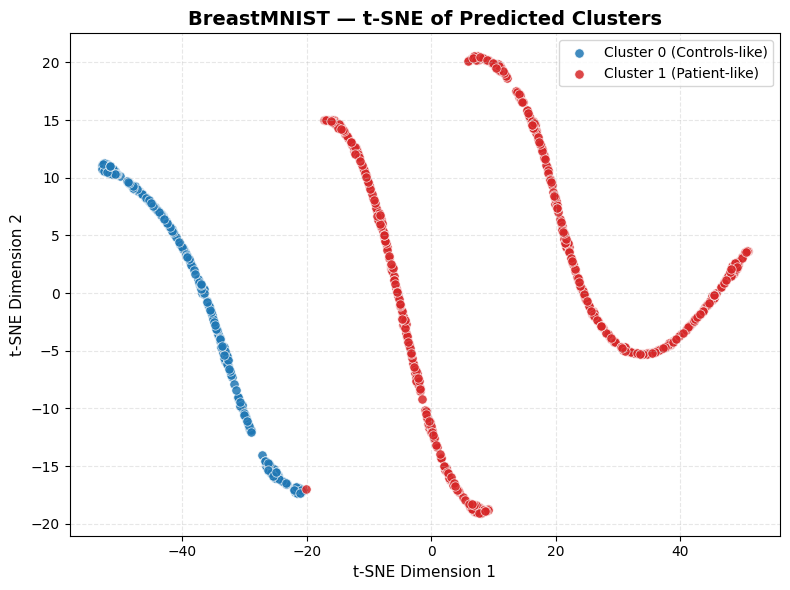

Saved: tsne_predicted_ADNI.png


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ================= t-SNE ON LEARNED EMBEDDINGS =================
print("\n===== t-SNE (Predicted Clusters Only) =====\n")

model.eval()
with torch.no_grad():
    S1, _, logits1, _, _, _ = model(data0, data0)

    embeddings = S1.cpu().numpy()
    y_pred_tsne = torch.argmax(logits1, dim=1).cpu().numpy()

# Optional label flip (for consistency)
y_true_np_aligned = y_labels # Use y_labels as it corresponds to the sampled features
acc_n = accuracy_score(y_true_np_aligned, y_pred_tsne)
acc_i = accuracy_score(y_true_np_aligned, 1 - y_pred_tsne)
if acc_i > acc_n:
    y_pred_tsne = 1 - y_pred_tsne

# ================= t-SNE =================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

emb_2d = tsne.fit_transform(embeddings)

# ================= PLOT =================
plt.figure(figsize=(8, 6))

# 🔥 Better scientific colors
colors = ['#1f77b4', '#d62728']  # blue & red
labels = ['Cluster 0 (Controls-like)', 'Cluster 1 (Patient-like)']

for k in range(2):
    idx = (y_pred_tsne == k)
    plt.scatter(
        emb_2d[idx, 0], emb_2d[idx, 1],
        c=colors[k],
        label=labels[k],
        s=45,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.5
    )

# ================= FORMATTING =================
plt.title("BreastMNIST — t-SNE of Predicted Clusters",
          fontsize=14, fontweight='bold')

plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("tsne_predicted_breast.png", dpi=200, bbox_inches='tight')
plt.show()

print("Saved: tsne_predicted_ADNI.png")

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)
import numpy as np
import random
import torch

num_runs = 10

acc_list, prec_list, rec_list, f1_list, logloss_list, nmi_list = [], [], [], [], [], []

for run in range(num_runs):
    print(f"\n===== RUN {run+1} =====")

    seed = 42 + run
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model     = ARMA(feats_dim, 64, K, device, activ, cut).to(device)
    optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=200, gamma=0.5)

    # -------------------- Training --------------------
    for epoch in range(num_epochs):

        W_aug1_edge_index = aug_random_edge_edge_index(
            edge_index_np, drop_percent=0.2, seed=epoch + seed)
        W_aug2_edge_index = aug_random_edge_edge_index(
            edge_index_np, drop_percent=0.2, seed=epoch + 999 + seed)

        rng  = np.random.default_rng(epoch + seed)
        mask = rng.random(features_np.shape) >= 0.2
        features_aug1 = features_np * mask.astype(np.float32)

        aug_feat2 = features_np.copy()
        num_nodes_local, feat_dim = aug_feat2.shape
        drop_feat_num = int(num_nodes_local * feat_dim * 0.2)
        flat_idx = rng.choice(num_nodes_local * feat_dim, size=drop_feat_num, replace=False)
        rows = flat_idx // feat_dim
        cols = flat_idx % feat_dim
        aug_feat2[rows, cols] = 0.0
        features_aug2 = aug_feat2.astype(np.float32)

        node_feats1, edge_index1 = load_data_from_edge_index(
            features_aug1, W_aug1_edge_index, device)
        data1 = Data(x=node_feats1.to(device), edge_index=edge_index1.to(device))

        node_feats2, edge_index2 = load_data_from_edge_index(
            features_aug2, W_aug2_edge_index, device)
        data2 = Data(x=node_feats2.to(device), edge_index=edge_index2.to(device))

        model.train()
        optimizer.zero_grad()

        S1, S2, logits1, logits2, l1, l2 = model(data1, data2)

        unsup_loss = model.loss(A1, logits1)
        cont_loss  = ((l1 + l2) / 2).mean()
        total_loss = unsup_loss + lambda_contrastive * cont_loss

        total_loss.backward()
        optimizer.step()
        scheduler.step()
        model.update_ma()

    model.eval()
    with torch.no_grad():
        S1, _, logits1, _, _, _ = model(data0, data0)
        y_pred_proba = torch.nn.functional.softmax(logits1, dim=1).cpu().numpy()
        y_pred       = np.argmax(y_pred_proba, axis=1)

    acc_score     = accuracy_score(y_labels, y_pred)
    acc_score_inv = accuracy_score(y_labels, 1 - y_pred)
    if acc_score_inv > acc_score:
        y_pred    = 1 - y_pred
        acc_score = acc_score_inv

    prec    = precision_score(y_labels, y_pred, zero_division=0)
    rec     = recall_score(y_labels, y_pred,    zero_division=0)
    f1_val  = f1_score(y_labels, y_pred,        zero_division=0)
    logloss = log_loss(y_labels, y_pred_proba)


    nmi = normalized_mutual_info_score(y_labels, y_pred, average_method='arithmetic')

    print(f"Acc: {acc_score:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | "
          f"F1: {f1_val:.4f} | NMI: {nmi:.4f}")

    acc_list.append(acc_score)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1_val)
    logloss_list.append(logloss)
    nmi_list.append(nmi)

# -------------------- Final Results --------------------
print("\n===== FINAL RESULTS (10 RUNS) =====")
print(f"Accuracy : {np.mean(acc_list):.4f}  ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(rec_list):.4f}  ± {np.std(rec_list):.4f}")
print(f"F1-score : {np.mean(f1_list):.4f}  ± {np.std(f1_list):.4f}")
print(f"NMI      : {np.mean(nmi_list):.4f}  ± {np.std(nmi_list):.4f}")
print(f"Log Loss : {np.mean(logloss_list):.4f}  ± {np.std(logloss_list):.4f}")


===== RUN 1 =====
Acc: 0.6282 | Prec: 0.7349 | Rec: 0.7684 | F1: 0.7513 | NMI: 0.0002

===== RUN 2 =====
Acc: 0.6359 | Prec: 0.7375 | Rec: 0.7789 | F1: 0.7577 | NMI: 0.0007

===== RUN 3 =====



KeyboardInterrupt



In [ ]:
import numpy as np
import random
import torch
import torch.nn.functional as nnFn
from torch.optim.lr_scheduler import StepLR
from torch.optim import AdamW
from torch_geometric.data import Data
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score  # <-- added
)

NUM_RUNS = 10

acc_list, prec_list, rec_list, f1_list, logloss_list, nmi_list = [], [], [], [], [], []  # <-- added nmi_list

for run in range(NUM_RUNS):
    print(f"\n===== RUN {run+1}/{NUM_RUNS} =====")

    # -------- seeds --------
    np.random.seed(42 + run)
    random.seed(42 + run)
    torch.manual_seed(42 + run)

    # -------- model / optimizer --------
    feats_dim = features.shape[1]
    model     = ARMA(feats_dim, 256, K, device, activ, cut).to(device)
    optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=200, gamma=0.5)

    num_epochs         = 5000
    lambda_contrastive = 0.1

    # -------- training loop --------
    for epoch in range(num_epochs):

        W_aug1_edge_index = aug_random_edge_edge_index(
            edge_index_np, drop_percent=0.2, seed=epoch)
        W_aug2_edge_index = aug_random_edge_edge_index(
            edge_index_np, drop_percent=0.2, seed=epoch + 999)

        rng  = np.random.default_rng(epoch)
        mask = rng.random(features_np.shape) >= 0.2
        features_aug1 = features_np * mask.astype(np.float32)

        aug_feat2              = features_np.copy()
        n_nodes, feat_dim      = aug_feat2.shape
        drop_feat_num          = int(n_nodes * feat_dim * 0.2)
        flat_idx               = rng.choice(n_nodes * feat_dim, size=drop_feat_num, replace=False)
        aug_feat2[flat_idx // feat_dim, flat_idx % feat_dim] = 0.0
        features_aug2          = aug_feat2.astype(np.float32)

        node_feats1, edge_index1 = load_data_from_edge_index(
            features_aug1, W_aug1_edge_index, device)
        data1 = Data(x=node_feats1.to(device), edge_index=edge_index1.to(device))

        node_feats2, edge_index2 = load_data_from_edge_index(
            features_aug2, W_aug2_edge_index, device)
        data2 = Data(x=node_feats2.to(device), edge_index=edge_index2.to(device))

        model.train()
        optimizer.zero_grad()

        S1, S2, logits1, logits2, l1, l2 = model(data1, data2)
        unsup_loss = model.loss(A1, logits1)
        cont_loss  = ((l1 + l2) / 2).mean()
        total_loss = unsup_loss + lambda_contrastive * cont_loss

        total_loss.backward()
        optimizer.step()
        scheduler.step()
        model.update_ma()

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Total: {total_loss.item():.4f} "
                  f"| Unsup: {unsup_loss.item():.4f} | Cont: {cont_loss.item():.4f}")

    # -------- evaluation (final model only) --------
    model.eval()
    with torch.no_grad():
        S1, _, logits1, _, _, _ = model(data0, data0)
        y_pred_proba = nnFn.softmax(logits1, dim=1).cpu().numpy()
        y_pred       = np.argmax(y_pred_proba, axis=1)

    acc     = accuracy_score(y_labels, y_pred)
    acc_inv = accuracy_score(y_labels, 1 - y_pred)
    if acc_inv > acc:
        acc    = acc_inv
        y_pred = 1 - y_pred

    prec = precision_score(y_labels, y_pred, zero_division=0)
    rec  = recall_score(y_labels, y_pred,    zero_division=0)
    f1   = f1_score(y_labels, y_pred,        zero_division=0)
    ll   = log_loss(y_labels, y_pred_proba)

    # ── NMI: one value per run, final model only ──
    nmi  = normalized_mutual_info_score(y_labels, y_pred, average_method='arithmetic')

    acc_list.append(acc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    logloss_list.append(ll)
    nmi_list.append(nmi)       # <-- added

    print(f"Run {run+1} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | "
          f"F1: {f1:.4f} | NMI: {nmi:.4f} | LogLoss: {ll:.4f}")

# -------- final summary --------
def mean_std(a):
    return np.mean(a), np.std(a)

print("\n===== FINAL RESULTS OVER 10 RUNS =====")
m, s = mean_std(acc_list);      print(f"Accuracy : {m:.4f} ± {s:.4f}")
m, s = mean_std(prec_list);     print(f"Precision: {m:.4f} ± {s:.4f}")
m, s = mean_std(rec_list);      print(f"Recall   : {m:.4f} ± {s:.4f}")
m, s = mean_std(f1_list);       print(f"F1       : {m:.4f} ± {s:.4f}")
m, s = mean_std(nmi_list);      print(f"NMI      : {m:.4f} ± {s:.4f}")   # <-- added
m, s = mean_std(logloss_list);  print(f"Log Loss : {m:.4f} ± {s:.4f}")

In [ ]:
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# import numpy as np

# # ---- Input features ----
# X_input = features

# # ---- Labels ----
# labels = y_labels

# # ---- Run t-SNE on input features ----
# tsne_input = TSNE(
#     n_components=2,
#     perplexity=30,
#     learning_rate=200,
#     init="pca",
#     random_state=42
# )

# X_2d = tsne_input.fit_transform(X_input)

# # ---- Plot t-SNE (Input Space) ----
# plt.figure(figsize=(6.5, 5.5))

# scatter = plt.scatter(
#     X_2d[:, 0],
#     X_2d[:, 1],
#     c=labels,
#     cmap="coolwarm",
#     s=25,
#     alpha=0.85
# )

# # ---- Legend ----
# legend = plt.legend(
#     *scatter.legend_elements(),
#     title="Class",
#     loc="best"
# )
# plt.gca().add_artist(legend)

# # ---- Formatting ----
# plt.title("t-SNE of Input Features (BreastMNIST)")
# plt.xlabel("t-SNE Dimension 1")
# plt.ylabel("t-SNE Dimension 2")
# plt.grid(alpha=0.3)
# plt.tight_layout()

# plt.show()


In [ ]:
# import numpy as np
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

# NUM_RUNS = 10

# acc_list = []
# prec_list = []
# rec_list = []
# f1_list = []
# logloss_list = []

# for run in range(NUM_RUNS):
#     print(f"\n===== RUN {run+1}/{NUM_RUNS} =====")

#     from torch.optim.lr_scheduler import StepLR
#     from torch.optim import AdamW

#     feats_dim = features.shape[1]
#     model = ARMA(feats_dim, 256, K, device, activ, cut).to(device)
#     optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
#     scheduler = StepLR(optimizer, step_size=200, gamma=0.5)

#     # Seeds
#     np.random.seed(42 + run)
#     random.seed(42 + run)
#     torch.manual_seed(42 + run)

#     num_epochs = 2500
#     lambda_contrastive = 0.001

#     for epoch in range(num_epochs):
#         # -------- augmentations --------
#         W_aug1_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch)
#         W_aug2_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch + 999)

#         rng = np.random.default_rng(epoch)
#         mask = rng.random(features_np.shape) >= 0.2
#         features_aug1 = (features_np * mask.astype(np.float32))

#         aug_feat2 = features_np.copy()
#         n_nodes, feat_dim = aug_feat2.shape
#         drop_feat_num = int(n_nodes * feat_dim * 0.2)
#         flat_idx = rng.choice(n_nodes * feat_dim, size=drop_feat_num, replace=False)
#         rows = flat_idx // feat_dim
#         cols = flat_idx % feat_dim
#         aug_feat2[rows, cols] = 0.0
#         features_aug2 = aug_feat2.astype(np.float32)

#         node_feats1, edge_index1 = load_data_from_edge_index(features_aug1, W_aug1_edge_index, device)
#         data1 = Data(x=node_feats1.to(device), edge_index=edge_index1.to(device))

#         node_feats2, edge_index2 = load_data_from_edge_index(features_aug2, W_aug2_edge_index, device)
#         data2 = Data(x=node_feats2.to(device), edge_index=edge_index2.to(device))

#         # -------- training --------
#         model.train()
#         optimizer.zero_grad()

#         S1, S2, logits1, logits2, l1, l2 = model(data1, data2)

#         unsup_loss = model.loss(A1, logits1)
#         cont_loss = ((l1 + l2) / 2).mean()
#         total_loss = unsup_loss + lambda_contrastive * cont_loss

#         total_loss.backward()
#         optimizer.step()
#         scheduler.step()
#         model.update_ma()

#         if epoch % 100 == 0:
#             print(f"Epoch {epoch} | Total: {total_loss.item():.4f} "
#                   f"| Unsup: {unsup_loss.item():.4f} | Cont: {cont_loss.item():.4f}")

#     # -------- evaluation --------
#     model.eval()
#     with torch.no_grad():
#         S1, _, logits1, _, _, _ = model(data0, data0)
#         y_pred_proba = nnFn.softmax(logits1, dim=1).cpu().numpy()
#         y_pred = np.argmax(y_pred_proba, axis=1)

#     acc = accuracy_score(y_labels, y_pred)
#     acc_inv = accuracy_score(y_labels, 1 - y_pred)
#     if acc_inv > acc:   # flip if class labels reversed
#         acc = acc_inv
#         y_pred = 1 - y_pred

#     prec = precision_score(y_labels, y_pred)
#     rec = recall_score(y_labels, y_pred)
#     f1 = f1_score(y_labels, y_pred)
#     ll = log_loss(y_labels, y_pred_proba)

#     acc_list.append(acc)
#     prec_list.append(prec)
#     rec_list.append(rec)
#     f1_list.append(f1)
#     logloss_list.append(ll)

# # -------- mean ± std printing --------
# def mean_std(a):
#     return np.mean(a), np.std(a)

# print("\n===== FINAL RESULTS OVER 10 RUNS =====")
# m, s = mean_std(acc_list);     print(f"Accuracy: {m:.4f} ± {s:.4f}")
# m, s = mean_std(prec_list);    print(f"Precision: {m:.4f} ± {s:.4f}")
# m, s = mean_std(rec_list);     print(f"Recall: {m:.4f} ± {s:.4f}")
# m, s = mean_std(f1_list);      print(f"F1: {m:.4f} ± {s:.4f}")
# m, s = mean_std(logloss_list); print(f"Log Loss: {m:.4f} ± {s:.4f}")


alpha = 0.2, Accuracy 0.725 $\pm$ 0.01 & Precision 0.733 $\pm$ 0.00 & Recall 0.982 $\pm$ 0.01 & F1 0.839 $\pm$ 0.00 \
alpha = 0.4
Accuracy: 0.7208 ± 0.0000
Precision: 0.7208 ± 0.0000
Recall: 1.0000 ± 0.0000
F1: 0.8444 ± 0.0000 \
alpha = 0.75
Accuracy: 0.7155 ± 0.0101
Precision: 0.7308 ± 0.0029
Recall: 0.9668 ± 0.0144
F1: 0.8324 ± 0.0070 \
alpha = 0.8
Accuracy: 0.7012 ± 0.0144
Precision: 0.7337 ± 0.0043
Recall: 0.9277 ± 0.0249
F1: 0.8193 ± 0.0111 \
alpha = 0.85
Accuracy: 0.6400 ± 0.0201
Precision: 0.7151 ± 0.0113
Recall: 0.8433 ± 0.0183
F1: 0.7739 ± 0.0133

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, normalized_mutual_info_score

num_runs = 10
num_epochs = 5000
lr = 1e-4
weight_decay = 1e-4
# Define the list of alpha values to search
alpha_list = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75] # Updated alpha list for grid search
base_seed = 42

all_results = []

# Fix lambda_contrastive to the previously determined best value
lambda_contrastive_fixed = 0.010

for current_alpha in alpha_list:
    print(f"\n================ ALPHA = {current_alpha} ================\n")

    acc_scores, prec_scores, rec_scores, f1_scores, log_losses, nmi_scores = [], [], [], [], [], []

    for run in range(num_runs):
        print(f"\n--- Run {run + 1}/{num_runs} ---")
        torch.manual_seed(base_seed + run)
        np.random.seed(base_seed + run)
        random.seed(base_seed + run)

        # --- Model Setup ---
        model = ARMA(feats_dim, 256, K, device, activ, cut).to(device)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = StepLR(optimizer, step_size=200, gamma=0.5)

        # --- Create Adjacency Matrix and PyG Data objects for the current alpha ---
        # These need to be re-created for each alpha value
        W0 = create_adj(features, cut, current_alpha)  # shape (N, N) dense
        A1 = torch.from_numpy(W0).float().to(device)

        edge_index_np, edge_weight_np = edge_index_from_dense(W0)  # numpy edge_index (2, E)
        num_nodes = features.shape[0]
        adj_list = build_adj_list(edge_index_np, num_nodes)  # adjacency list for fast subgraph sampling

        # Build initial Data object (full graph) for evaluation
        node_feats_full, edge_index_full = load_data_from_edge_index(features_np, edge_index_np, device)
        data0 = Data(x=node_feats_full.to(device), edge_index=edge_index_full.to(device))

        for epoch in range(num_epochs):
            # 1) Two random edge augmentations
            W_aug1_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch)
            W_aug2_edge_index = aug_random_edge_edge_index(edge_index_np, drop_percent=0.2, seed=epoch + 999)

            # 2) Feature augmentations
            rng = np.random.default_rng(epoch)
            mask = rng.random(features_np.shape) >= 0.2
            features_aug1 = (features_np * mask.astype(np.float32))
            features_aug2 = features_np.copy()
            num_nodes_local, feat_dim = features_aug2.shape
            drop_feat_num = int(num_nodes_local * feat_dim * 0.2)
            flat_idx = rng.choice(num_nodes_local * feat_dim, size=drop_feat_num, replace=False)
            rows = (flat_idx // feat_dim)
            cols = (flat_idx % feat_dim)
            features_aug2[rows, cols] = 0.0
            features_aug2_feat = features_aug2.astype(np.float32)

            # 3) Build Data views
            node_feats1, edge_index1 = load_data_from_edge_index(features_aug1, W_aug1_edge_index, device)
            data1 = Data(x=node_feats1.to(device), edge_index=edge_index1.to(device))
            node_feats2, edge_index2 = load_data_from_edge_index(features_aug2_feat, W_aug2_edge_index, device)
            data2 = Data(x=node_feats2.to(device), edge_index=edge_index2.to(device))

            # --- Training step ---
            model.train()
            optimizer.zero_grad()

            S1, S2, logits1, logits2, l1, l2 = model(data1, data2)
            unsup_loss = model.loss(A1, logits1)
            cont_loss = ((l1 + l2) / 2).mean()
            total_loss = unsup_loss + lambda_contrastive_fixed * cont_loss

            total_loss.backward()
            optimizer.step()
            scheduler.step()
            model.update_ma()

            if epoch % 500 == 0:
                print(f"Epoch {epoch} | Total: {total_loss.item():.4f} | Unsup: {unsup_loss.item():.4f} | Cont: {cont_loss.item():.4f}")

        # --- Evaluation ---
        model.eval()
        with torch.no_grad():
            S1, _, logits1, _, _, _ = model(data0, data0)
            y_pred_proba = nnFn.softmax(logits1, dim=1).cpu().numpy()
            y_pred = np.argmax(y_pred_proba, axis=1)

        acc = accuracy_score(y_labels, y_pred)
        acc_inv = accuracy_score(y_labels, 1 - y_pred)
        if acc_inv > acc:
            acc = acc_inv
            y_pred = 1 - y_pred

        prec = precision_score(y_labels, y_pred, zero_division=0)
        rec = recall_score(y_labels, y_pred, zero_division=0)
        f1 = f1_score(y_labels, y_pred, zero_division=0)
        ll = log_loss(y_labels, y_pred_proba)
        nmi = normalized_mutual_info_score(y_labels, y_pred, average_method='arithmetic')

        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)
        f1_scores.append(f1)
        log_losses.append(ll)
        nmi_scores.append(nmi)

        print(f"Run {run + 1} Accuracy: {acc:.4f}, F1: {f1:.4f}, NMI: {nmi:.4f}")

    # --- Aggregate Results ---
    alpha_results = {
        "alpha": current_alpha,
        "accuracy": (np.mean(acc_scores), np.std(acc_scores)),
        "precision": (np.mean(prec_scores), np.std(prec_scores)),
        "recall": (np.mean(rec_scores), np.std(rec_scores)),
        "f1": (np.mean(f1_scores), np.std(f1_scores)),
        "log_loss": (np.mean(log_losses), np.std(log_losses)),
        "nmi": (np.mean(nmi_scores), np.std(nmi_scores))
    }
    all_results.append(alpha_results)

    print(f"\n--- RESULTS FOR ALPHA = {current_alpha} ---")
    print(f"Accuracy: {alpha_results['accuracy'][0]:.4f} \u00B1 {alpha_results['accuracy'][1]:.4f}")
    print(f"Precision: {alpha_results['precision'][0]:.4f} \u00B1 {alpha_results['precision'][1]:.4f}")
    print(f"Recall: {alpha_results['recall'][0]:.4f} \u00B1 {alpha_results['recall'][1]:.4f}")
    print(f"F1 Score: {alpha_results['f1'][0]:.4f} \u00B1 {alpha_results['f1'][1]:.4f}")
    print(f"Log Loss: {alpha_results['log_loss'][0]:.4f} \u00B1 {alpha_results['log_loss'][1]:.4f}")
    print(f"NMI: {alpha_results['nmi'][0]:.4f} \u00B1 {alpha_results['nmi'][1]:.4f}")

# ==========================================================
# === Final Summary ===
# ==========================================================
print("\n================ FINAL SUMMARY FOR ALL ALPHAS ================\n")
print(f"{'Alpha':>8} | {'Accuracy':>18} | {'Precision':>18} | {'Recall':>18} | {'F1 Score':>18} | {'Log Loss':>18} | {'NMI':>18}")
print("-" * 129)
for res in all_results:
    print(f"{res['alpha']:>8} | "
          f"{res['accuracy'][0]:.4f} \u00B1 {res['accuracy'][1]:.4f} | "
          f"{res['precision'][0]:.4f} \u00B1 {res['precision'][1]:.4f} | "
          f"{res['recall'][0]:.4f} \u00B1 {res['recall'][1]:.4f} | "
          f"{res['f1'][0]:.4f} \u00B1 {res['f1'][1]:.4f} | "
          f"{res['log_loss'][0]:.4f} \u00B1 {res['log_loss'][1]:.4f} | "
          f"{res['nmi'][0]:.4f} \u00B1 {res['nmi'][1]:.4f}")


================ ALPHA = 0.05 ================


--- Run 1/10 ---
Epoch 0 | Total: -0.1671 | Unsup: -0.2375 | Cont: 7.0419
Epoch 500 | Total: -0.4097 | Unsup: -0.4797 | Cont: 7.0023
Epoch 1000 | Total: -0.4144 | Unsup: -0.4842 | Cont: 6.9788
Epoch 1500 | Total: -0.4170 | Unsup: -0.4869 | Cont: 6.9898
Epoch 2000 | Total: -0.4201 | Unsup: -0.4896 | Cont: 6.9468
Epoch 2500 | Total: -0.4169 | Unsup: -0.4868 | Cont: 6.9867
Epoch 3000 | Total: -0.4143 | Unsup: -0.4842 | Cont: 6.9853
Epoch 3500 | Total: -0.4207 | Unsup: -0.4900 | Cont: 6.9216
Epoch 4000 | Total: -0.4214 | Unsup: -0.4911 | Cont: 6.9704
Epoch 4500 | Total: -0.4197 | Unsup: -0.4896 | Cont: 6.9907
Run 1 Accuracy: 0.7282, F1: 0.8399, NMI: 0.0080

--- Run 2/10 ---
Epoch 0 | Total: -0.1668 | Unsup: -0.2372 | Cont: 7.0452
Epoch 500 | Total: -0.4084 | Unsup: -0.4789 | Cont: 7.0446
Epoch 1000 | Total: -0.4058 | Unsup: -0.4762 | Cont: 7.0470
Epoch 1500 | Total: -0.4165 | Unsup: -0.4872 | Cont: 7.0619
Epoch 2000 | Total: -0.4089 | Unsup